<a href="https://colab.research.google.com/github/anabeasva/predicao-diabetes-naive-bayes/blob/main/naive_bayes_diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# bibliotecas
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# upload do arquivo no google colab
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes (4).csv


In [ ]:
# lendo o arquivo
dados = pd.read_csv("diabetes.csv")

# renomeando colunas para português
dados.columns = [
    'Gravidezes', 'Glicose', 'Pressao', 'Pele',
    'Insulina', 'IMC', 'Historico', 'Idade', 'Resultado'
]

In [ ]:
print(dados.head())
print("Tamanho:", dados.shape)
print("Nulos:\n", dados.isnull().sum())

   Gravidezes  Glicose  Pressao  Pele  Insulina   IMC  Historico  Idade  \
0           6      148       72    35         0  33.6      0.627     50   
1           1       85       66    29         0  26.6      0.351     31   
2           8      183       64     0         0  23.3      0.672     32   
3           1       89       66    23        94  28.1      0.167     21   
4           0      137       40    35       168  43.1      2.288     33   

   Resultado  
0          1  
1          0  
2          1  
3          0  
4          1  
Tamanho: (768, 9)
Nulos:
 Gravidezes    0
Glicose       0
Pressao       0
Pele          0
Insulina      0
IMC           0
Historico     0
Idade         0
Resultado     0
dtype: int64


In [ ]:
X = dados.drop('Resultado', axis=1)
y = dados['Resultado']

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
colunas = ['Glicose', 'Pressao', 'Pele', 'Insulina', 'IMC']

# zeros viram NaN
X_treino[colunas] = X_treino[colunas].replace(0, np.nan)
X_teste[colunas]  = X_teste[colunas].replace(0, np.nan)

# mediana calculada só com o treino
mediana = X_treino[colunas].median()

# preenche os NaN com a mediana
X_treino[colunas] = X_treino[colunas].fillna(mediana)
X_teste[colunas]  = X_teste[colunas].fillna(mediana)

In [ ]:
modelo = GaussianNB()
modelo.fit(X_treino, y_treino)

previsoes = modelo.predict(X_teste)

Acurácia: 0.7597402597402597

Relatório de Classificação:
              precision    recall  f1-score   support

Sem Diabetes       0.82      0.80      0.81        99
Com Diabetes       0.66      0.69      0.67        55

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154



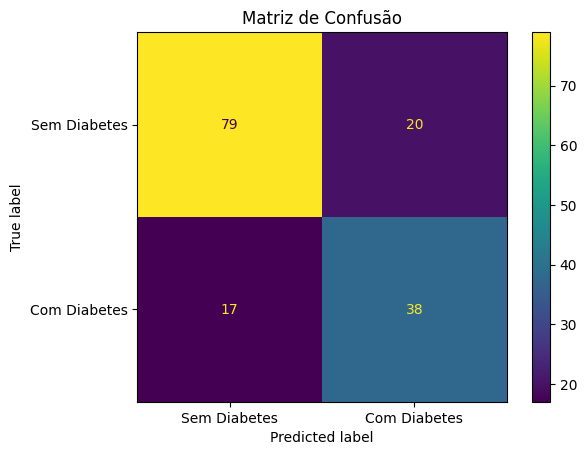

In [ ]:
print("Acurácia:", accuracy_score(y_teste, previsoes))

print("\nRelatório de Classificação:")
print(classification_report(y_teste, previsoes, target_names=["Sem Diabetes", "Com Diabetes"]))

# matriz de confusão
matriz = confusion_matrix(y_teste, previsoes)
ConfusionMatrixDisplay(matriz, display_labels=["Sem Diabetes", "Com Diabetes"]).plot()
plt.title("Matriz de Confusão")
plt.show()